Natural Language Inferencing (NLI) is a classic NLP (Natural Language Processing) problem that involves taking two sentences (the _premise_ and the _hypothesis_ ), and deciding how they are related- if the premise entails the hypothesis, contradicts it, or neither.

In this tutorial we'll look at the _Contradictory, My Dear Watson_ competition dataset, build a preliminary model using PyTorch, Hugging Face Transformers, and BERT, and prepare a submission file.

This is a local, PyTorch-based adaptation of the original Kaggle TensorFlow/Keras tutorial notebook.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Local run: data files live in the same directory as this notebook
import os
for filename in os.listdir('.'):
    if filename.endswith('.csv'):
        print(filename)

sample_submission.csv
submission.csv
test.csv
train.csv


In [2]:
import truststore
truststore.inject_into_ssl()  # trust the OS cert store (fixes HF Hub downloads behind the corporate proxy)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt

C:\Users\alher\Desktop\Watson\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We fix a random seed before any model init / data shuffling. Baseline val_accuracy swung ~1.3 points across identical runs (62.8%–64.0%) purely from `DataLoader` shuffling and the new classifier's random init — fixing the seed removes most of that noise so future A/B comparisons (e.g. regularization, pooling strategy) reflect a real effect rather than a lucky draw. Note this doesn't guarantee bit-exact GPU determinism (cuDNN kernels aren't fully deterministic by default), but it removes the dominant source of variance we were seeing.

In [3]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Let's set up our device (GPU if available, otherwise CPU).

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


The training set contains a premise, a hypothesis, a label (0 = entailment, 1 = neutral, 2 = contradiction), and the language of the text. For more information about what these mean and how the data is structured, check out the data page: https://www.kaggle.com/c/contradictory-my-dear-watson/data

In [5]:
train = pd.read_csv("train.csv")

In [6]:
train.head()

,id,premise,hypothesis,lang_abv,language,label
0,5130fd2cb5,and these comments were considered in formulat...,The rules developed in the interim were put to...,en,English,0
1,5b72532a0b,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,en,English,2
2,3931fbe82a,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,fr,French,0
3,5622f0c60b,you know they can't really defend themselves l...,They can't defend themselves because of their ...,en,English,0
4,86aaa48b45,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,Thai,1


Let's look at one of the pairs of sentences.

In [7]:
train.premise.values[1]

'These are issues that we wrestle with in practice groups of law firms, she said. '

In [8]:
train.hypothesis.values[1]

'Practice groups are not permitted to work on these issues.'

In [9]:
train.label.values[1]

2

These statements are contradictory, and the label shows that.

Let's look at the distribution of languages in the training set.

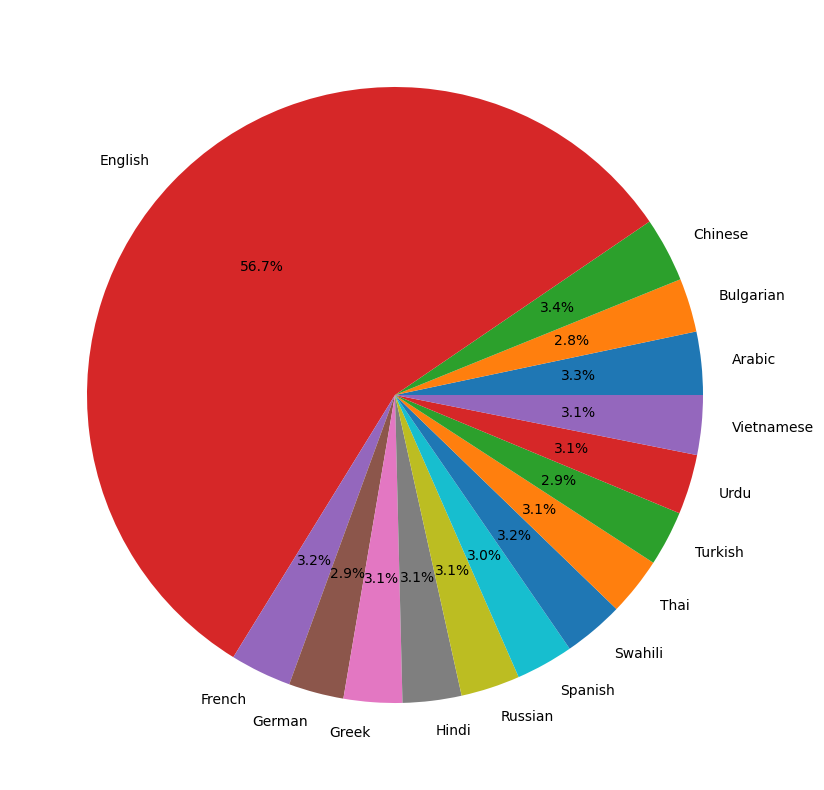

In [10]:
labels, frequencies = np.unique(train.language.values, return_counts = True)

plt.figure(figsize = (10,10))
plt.pie(frequencies,labels = labels, autopct = '%1.1f%%')
plt.show()

## Preparing Data for Input

To start out, we can use a pretrained model. Here, we'll use a multilingual BERT model from huggingface. For more information about BERT, see: https://github.com/google-research/bert/blob/master/multilingual.md

First, we download the tokenizer.

In [11]:
model_name = 'bert-base-multilingual-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

Tokenizers turn sequences of words into arrays of numbers. Let's look at an example:

In [12]:
def encode_sentence(s):
    return tokenizer.encode(s, add_special_tokens=False) + [tokenizer.sep_token_id]

In [13]:
encode_sentence("I love machine learning")

[146, 16138, 21432, 26901, 102]

BERT uses three kind of input data- input word IDs, input masks, and input type IDs.

These allow the model to know that the premise and hypothesis are distinct sentences, and also to ignore any padding from the tokenizer.

We add a [CLS] token to denote the beginning of the inputs, and a [SEP] token to denote the separation between the premise and the hypothesis. We also need to pad all of the inputs to be the same size. For more information about BERT inputs, see: https://huggingface.co/transformers/model_doc/bert.html#bertmodel

Now, we're going to encode all of our premise/hypothesis pairs for input into BERT.

`max_len` was originally 50, but with the mDeBERTa tokenizer that truncates 45.8% of premise+hypothesis pairs (median full length: 48 tokens) — often cutting off the hypothesis entirely, which is half the information the model needs to classify entailment/neutral/contradiction. Raised to 128, which covers 99.4% of examples untruncated. This is a shared preprocessing constant used by both the baseline and mDeBERTa sections, so it's fixed for both to keep the comparison fair.

In [14]:
max_len = 128  # con el tokenizer de mDeBERTa, max_len=50 truncaba el 45.8% de los ejemplos (mediana premise+hypothesis: 48 tokens); 128 cubre el 99.4%

def bert_encode(premises, hypotheses, tokenizer, max_len=max_len):
    encodings = tokenizer(
        list(premises), list(hypotheses),
        padding='max_length', truncation=True, max_length=max_len,
        return_tensors='pt')
    return {
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'token_type_ids': encodings['token_type_ids'],
    }

In [15]:
train_input = bert_encode(train.premise.values, train.hypothesis.values, tokenizer)

In [16]:
from sklearn.model_selection import train_test_split

class NLIDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['label'] = self.labels[idx]
        return item

labels = torch.tensor(train.label.values, dtype=torch.long)
train_idx, val_idx = train_test_split(
    np.arange(len(labels)), test_size=0.2, random_state=42)

train_encodings = {k: v[train_idx] for k, v in train_input.items()}
val_encodings = {k: v[val_idx] for k, v in train_input.items()}

train_dataset = NLIDataset(train_encodings, labels[train_idx])
val_dataset = NLIDataset(val_encodings, labels[val_idx])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

## Creating & Training Model

Now, we can incorporate the BERT transformer into a PyTorch model. This model was inspired by the model in this notebook: https://www.kaggle.com/tanulsingh077/deep-learning-for-nlp-zero-to-transformers-bert#BERT-and-Its-Implementation-on-this-Competition, which is a wonderful introduction to NLP!

In [17]:
class NLIModel(nn.Module):
    def __init__(self, model_name, num_labels=3, dropout=0.0, pooling='cls'):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)
        self.pooling = pooling

    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids)
        hidden_states = outputs.last_hidden_state
        if self.pooling == 'mean':
            mask = attention_mask.unsqueeze(-1).type_as(hidden_states)
            pooled = (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        else:
            pooled = hidden_states[:, 0, :]
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

In [18]:
model = NLIModel(model_name).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {num_params:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4232.05it/s]


[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 177,855,747


We also checkpoint the model weights after every epoch — `baseline_last.pt` is overwritten each epoch, while `baseline_best.pt` is only updated when validation loss improves — and apply early stopping if validation loss hasn't improved for 5 consecutive epochs.

In [19]:
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

epochs = 2
patience = 5
best_val_loss = float('inf')
baseline_best_val_accuracy = None
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, token_type_ids)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_labels.size(0)
        train_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            batch_labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask, token_type_ids)
            loss = criterion(logits, batch_labels)

            val_loss += loss.item() * batch_labels.size(0)
            val_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
            val_total += batch_labels.size(0)

    baseline_val_accuracy = val_correct / val_total
    avg_val_loss = val_loss / val_total
    print(f'Epoch {epoch+1}/{epochs} - '
          f'loss: {train_loss/train_total:.4f} - accuracy: {train_correct/train_total:.4f} - '
          f'val_loss: {avg_val_loss:.4f} - val_accuracy: {baseline_val_accuracy:.4f}')

    # Checkpointing: "last" is overwritten every epoch, "best" only when val_loss improves
    torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'baseline_last.pt'))

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        baseline_best_val_accuracy = baseline_val_accuracy
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'baseline_best.pt'))
        print(f'  -> new best val_loss ({best_val_loss:.4f}), saved to baseline_best.pt')
    else:
        epochs_no_improve += 1
        print(f'  -> val_loss did not improve for {epochs_no_improve} epoch(s) (best: {best_val_loss:.4f})')
        if epochs_no_improve >= patience:
            print(f'Early stopping: no val_loss improvement for {patience} consecutive epochs.')
            break

Epoch 1/2 - loss: 0.9435 - accuracy: 0.5409 - val_loss: 0.8112 - val_accuracy: 0.6399


  -> new best val_loss (0.8112), saved to baseline_best.pt


Epoch 2/2 - loss: 0.7195 - accuracy: 0.6908 - val_loss: 0.8004 - val_accuracy: 0.6588


  -> new best val_loss (0.8004), saved to baseline_best.pt


Since this is a 3-class classification problem (entailment / neutral / contradiction), accuracy alone hides *which* classes get confused with each other. We reload the best checkpoint (lowest val_loss, not necessarily the last epoch trained) and plot the confusion matrix on the validation split.

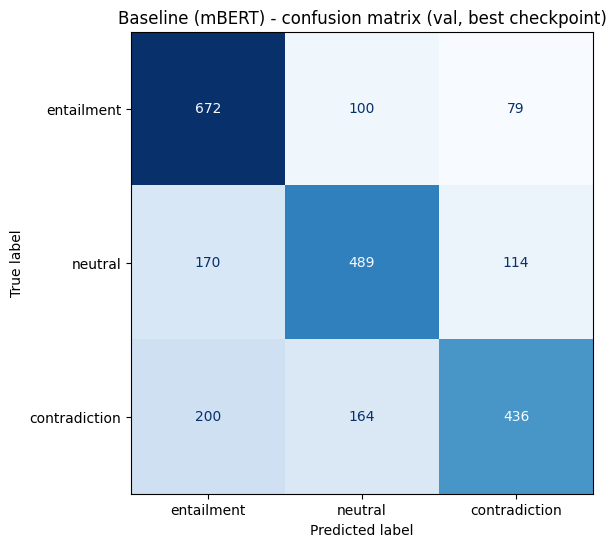

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ['entailment', 'neutral', 'contradiction']

model.load_state_dict(torch.load(os.path.join(checkpoint_dir, 'baseline_best.pt')))
model.eval()

val_preds, val_true = [], []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, token_type_ids)
        val_preds.extend(logits.argmax(dim=-1).cpu().tolist())
        val_true.extend(batch_labels.cpu().tolist())

cm = confusion_matrix(val_true, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Baseline (mBERT) - confusion matrix (val, best checkpoint)')
plt.show()

In [21]:
test = pd.read_csv("test.csv")
test_input = bert_encode(test.premise.values, test.hypothesis.values, tokenizer)

In [22]:
test.head()

,id,premise,hypothesis,lang_abv,language
0,c6d58c3f69,بکس، کیسی، راہیل، یسعیاہ، کیلی، کیلی، اور کولم...,"کیسی کے لئے کوئی یادگار نہیں ہوگا, کولمین ہائی...",ur,Urdu
1,cefcc82292,هذا هو ما تم نصحنا به.,عندما يتم إخبارهم بما يجب عليهم فعله ، فشلت ال...,ar,Arabic
2,e98005252c,et cela est en grande partie dû au fait que le...,Les mères se droguent.,fr,French
3,58518c10ba,与城市及其他公民及社区组织代表就IMA的艺术发展进行对话&amp,IMA与其他组织合作，因为它们都依靠共享资金。,zh,Chinese
4,c32b0d16df,Она все еще была там.,"Мы думали, что она ушла, однако, она осталась.",ru,Russian


## Generating & Submitting Predictions

In [23]:
model.eval()
predictions = []
with torch.no_grad():
    for i in range(0, len(test), batch_size):
        input_ids = test_input['input_ids'][i:i+batch_size].to(device)
        attention_mask = test_input['attention_mask'][i:i+batch_size].to(device)
        token_type_ids = test_input['token_type_ids'][i:i+batch_size].to(device)
        logits = model(input_ids, attention_mask, token_type_ids)
        predictions.extend(logits.argmax(dim=-1).cpu().tolist())

The submission file will consist of the ID column and a prediction column. We can just copy the ID column from the test file, make it a dataframe, and then add our prediction column.

In [24]:
submission = test.id.copy().to_frame()
submission['prediction'] = predictions

In [25]:
submission.head()

,id,prediction
0,c6d58c3f69,2
1,cefcc82292,1
2,e98005252c,0
3,58518c10ba,1
4,c32b0d16df,2


In [26]:
submission.to_csv("submission.csv", index = False)

And now we've created our submission file, which can be submitted to the competition. Good luck!

## Mejora: transfer learning desde un modelo preentrenado en NLI (mDeBERTa)

El baseline de arriba parte de `bert-base-multilingual-cased`, preentrenado solo con masked-LM genérico — no sabe nada de NLI de partida, así que tiene que aprender la tarea entera durante el fine-tuning.

Aquí partimos en cambio de [`MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`](https://huggingface.co/MoritzLaurer/mDeBERTa-v3-base-mnli-xnli), que ya está fine-tuneado en MNLI + XNLI (mismo formato premise/hypothesis/entailment-neutral-contradiction que esta competición, en 100 idiomas). Congelamos las capas inferiores del encoder (features lingüísticas más genéricas, ya bien aprendidas) y solo entrenamos las últimas capas más un classifier head nuevo — transfer learning real en vez de fine-tuning completo desde cero.

In [27]:
model_name_nli = 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli'
tokenizer_nli = AutoTokenizer.from_pretrained(model_name_nli)
model_nli = NLIModel(model_name_nli, dropout=0.4, pooling='mean').float().to(device)  # el checkpoint se guardo en fp16; el classifier nuevo es fp32

total_params_nli = sum(p.numel() for p in model_nli.parameters())

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 4430.98it/s]


[transformers] DebertaV2Model LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.bias     | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Congelamos embeddings + capas inferiores del encoder; dejamos entrenables solo las últimas `K` capas del encoder y el classifier head nuevo. El naming de las capas de DeBERTa-v3 (`encoder.layer.{i}.*`) se verificó antes de escribir este filtro.

`K` empezó en 3. Ahora que `max_len=128` arregló el cuello de botella real (el truncamiento), probamos si más capacidad entrenable ayuda: subimos `K` a 6 (la mitad del encoder, 42.5M parámetros entrenables en vez de 21.3M) manteniendo el resto igual para aislar el efecto de este único cambio. Resultado: **el mismo techo exacto de val_accuracy (88.04%)**, pero alcanzado en la época 1 en vez de la 2, con overfitting posterior mucho más agresivo (train_accuracy 97.8% en la época 6) y un coste de entrenamiento mucho mayor (GPU al 100%, VRAM casi al límite, bastante más lento por época). Sin ninguna ganancia a cambio de ese coste, así que volvemos a `K=3`.

In [28]:
K = 3  # nº de capas superiores del encoder que se entrenan (de 12 en total)

for name, param in model_nli.bert.named_parameters():
    if name.startswith('encoder.layer.'):
        layer_idx = int(name.split('.')[2])
        param.requires_grad = layer_idx >= (model_nli.bert.config.num_hidden_layers - K)
    else:
        param.requires_grad = False

for param in model_nli.classifier.parameters():
    param.requires_grad = True

trainable_params_nli = sum(p.numel() for p in model_nli.parameters() if p.requires_grad)
print(f'Parametros entrenables: {trainable_params_nli:,} de {total_params_nli:,} '
      f'({trainable_params_nli/total_params_nli:.1%})')

Parametros entrenables: 21,265,923 de 278,221,059 (7.6%)


Volvemos a tokenizar premise/hypothesis con el tokenizer de mDeBERTa (vocabulario distinto al de mBERT) reutilizando el mismo split train/val (`train_idx`/`val_idx`) que el baseline, para que la comparación de métricas sea justa.

In [29]:
train_input_nli = bert_encode(train.premise.values, train.hypothesis.values, tokenizer_nli)

train_encodings_nli = {k: v[train_idx] for k, v in train_input_nli.items()}
val_encodings_nli = {k: v[val_idx] for k, v in train_input_nli.items()}

train_dataset_nli = NLIDataset(train_encodings_nli, labels[train_idx])
val_dataset_nli = NLIDataset(val_encodings_nli, labels[val_idx])

train_loader_nli = DataLoader(train_dataset_nli, batch_size=batch_size, shuffle=True)
val_loader_nli = DataLoader(val_dataset_nli, batch_size=batch_size)

Entrenamos solo los parámetros no congelados, con warmup + decaimiento lineal del learning rate y gradient clipping — prácticas estándar de fine-tuning de BERT que no estaban en el baseline. Igual que en el baseline, guardamos los pesos en cada epoch (`nli_last.pt` se sobrescribe siempre; `nli_best.pt` solo cuando mejora la val_loss) y aplicamos early stopping si la val_loss no mejora durante 5 epochs consecutivos — con hasta 15 epochs disponibles, esto evita seguir entrenando una vez el modelo converge.

En la primera ejecución se vio overfitting claro: train_accuracy siguió subiendo (hasta ~89%) mientras la val_loss empeoraba a partir de la época 2, así que el early stopping se quedó con esos pesos (~80.4% val_accuracy). Subir la regularización del classifier head (dropout `p=0.2→0.4`, `weight_decay` de 0.01 a 0.1) dio una mejora pequeña y acumulativa (~+0.25 puntos) pero el gap train/val apenas se movió — indicio de que el cuello de botella no está solo en el classifier nuevo, sino en cómo se agrega la representación de la secuencia.

Dos cambios más en esta ejecución: (1) semilla fija (`SEED = 42`, celda al principio del notebook) para que las comparaciones dejen de estar contaminadas por el ~1.3 puntos de ruido que vimos entre runs idénticos del baseline; (2) mean pooling en vez de usar solo el token `[CLS]` — se promedia `last_hidden_state` sobre todos los tokens no-padding (usando `attention_mask`), lo que aprovecha toda la secuencia en vez de un único vector. El baseline no se toca (sigue con `pooling='cls'` por defecto en `NLIModel`).

**Nota sobre esta ejecución concreta:** con la semilla fija, la última corrida completa (15 epochs, early stopping en la época 7) dio su mejor `val_loss` en la época 2 y no volvió a mejorar después. Para esta re-ejecución (pensada solo para regenerar el checkpoint y alimentar el análisis de accuracy por idioma más abajo) fijamos `epochs_nli = 2` en vez de 15 — nos ahorramos las 5 épocas que el patience necesitaba agotar sin cambiar qué pesos termina usando `nli_best.pt`. Si en el futuro se quiere volver a explorar si hay una época mejor más adelante (p. ej. tras cambiar algún hiperparámetro), hay que restaurar `epochs_nli = 15` para que el early stopping tenga margen real de actuar.

In [30]:
from transformers import get_linear_schedule_with_warmup

checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

optimizer_nli = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_nli.parameters()), lr=2e-5, weight_decay=0.1)

epochs_nli = 2  # la ultima ejecucion documentada (SEED=42 fijo) dio su mejor val_loss en la epoca 2; reentrenamos solo hasta ahi en vez de esperar a que el early stopping agote el patience en la epoca 7
patience_nli = 5
total_steps_nli = len(train_loader_nli) * epochs_nli
scheduler_nli = get_linear_schedule_with_warmup(
    optimizer_nli,
    num_warmup_steps=int(0.1 * total_steps_nli),
    num_training_steps=total_steps_nli)

best_val_loss_nli = float('inf')
nli_best_val_accuracy = None
epochs_no_improve_nli = 0

for epoch in range(epochs_nli):
    model_nli.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for batch in train_loader_nli:
        optimizer_nli.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        logits = model_nli(input_ids, attention_mask, token_type_ids)
        loss = criterion(logits, batch_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_nli.parameters(), max_norm=1.0)
        optimizer_nli.step()
        scheduler_nli.step()

        train_loss += loss.item() * batch_labels.size(0)
        train_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    model_nli.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader_nli:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            batch_labels = batch['label'].to(device)

            logits = model_nli(input_ids, attention_mask, token_type_ids)
            loss = criterion(logits, batch_labels)

            val_loss += loss.item() * batch_labels.size(0)
            val_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
            val_total += batch_labels.size(0)

    nli_val_accuracy = val_correct / val_total
    avg_val_loss_nli = val_loss / val_total
    print(f'Epoch {epoch+1}/{epochs_nli} - '
          f'loss: {train_loss/train_total:.4f} - accuracy: {train_correct/train_total:.4f} - '
          f'val_loss: {avg_val_loss_nli:.4f} - val_accuracy: {nli_val_accuracy:.4f}')

    # Checkpointing: "last" se sobrescribe cada epoch, "best" solo cuando mejora la val_loss
    torch.save(model_nli.state_dict(), os.path.join(checkpoint_dir, 'nli_last.pt'))

    if avg_val_loss_nli < best_val_loss_nli:
        best_val_loss_nli = avg_val_loss_nli
        nli_best_val_accuracy = nli_val_accuracy
        epochs_no_improve_nli = 0
        torch.save(model_nli.state_dict(), os.path.join(checkpoint_dir, 'nli_best.pt'))
        print(f'  -> nuevo mejor val_loss ({best_val_loss_nli:.4f}), guardado en nli_best.pt')
    else:
        epochs_no_improve_nli += 1
        print(f'  -> val_loss sin mejora desde hace {epochs_no_improve_nli} epoch(s) (mejor: {best_val_loss_nli:.4f})')
        if epochs_no_improve_nli >= patience_nli:
            print(f'Early stopping: sin mejora en val_loss durante {patience_nli} epochs consecutivos.')
            break

Epoch 1/2 - loss: 0.5071 - accuracy: 0.8045 - val_loss: 0.3334 - val_accuracy: 0.8771


  -> nuevo mejor val_loss (0.3334), guardado en nli_best.pt


Epoch 2/2 - loss: 0.3542 - accuracy: 0.8722 - val_loss: 0.3397 - val_accuracy: 0.8820


  -> val_loss sin mejora desde hace 1 epoch(s) (mejor: 0.3334)


Al ser un problema de clasificación de 3 clases (entailment / neutral / contradiction), la accuracy sola no muestra qué clases se confunden entre sí. Recargamos el checkpoint con mejor val_loss (`nli_best.pt`, no necesariamente el de la última época entrenada) y pintamos la matriz de confusión sobre el split de validación.

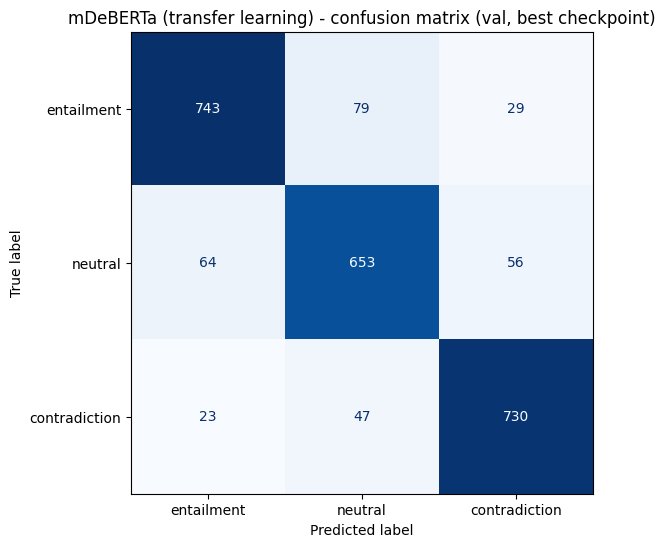

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ['entailment', 'neutral', 'contradiction']

model_nli.load_state_dict(torch.load(os.path.join(checkpoint_dir, 'nli_best.pt')))
model_nli.eval()

val_preds_nli, val_true_nli = [], []
with torch.no_grad():
    for batch in val_loader_nli:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        logits = model_nli(input_ids, attention_mask, token_type_ids)
        val_preds_nli.extend(logits.argmax(dim=-1).cpu().tolist())
        val_true_nli.extend(batch_labels.cpu().tolist())

cm_nli = confusion_matrix(val_true_nli, val_preds_nli)
disp_nli = ConfusionMatrixDisplay(confusion_matrix=cm_nli, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp_nli.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('mDeBERTa (transfer learning) - confusion matrix (val, best checkpoint)')
plt.show()

### Accuracy por idioma (mDeBERTa) — dónde augmentar con traducción

La accuracy global (88.0%) puede esconder que el modelo rinda bastante peor en algunos de los 15 idiomas del dataset. Reutilizamos `val_true_nli`/`val_preds_nli` (ya calculados con el mejor checkpoint) y los cruzamos con `train.language.values[val_idx]` para ver la accuracy idioma a idioma en el split de validación.

Esto es sobre el split de **validación**, no sobre `test.csv`: `test.csv` no trae la columna `label` (es el fichero de submission de Kaggle, sin ground truth), así que no hay forma de medir accuracy por idioma ahí directamente — el proxy fiable es el split de validación, que sí tiene etiquetas y viene del mismo `train.csv`.

Los idiomas por debajo de la accuracy global (en rojo) son los candidatos naturales para aumentar datos vía traducción: traducir premise/hypothesis de idiomas donde el modelo ya rinde bien hacia el idioma problemático, manteniendo la label original (la relación de entailment no cambia al traducir). Ojo con el tamaño de muestra: cada idioma no-inglés tiene ~350-400 filas en `train.csv` (~70-80 en validación), así que una accuracy individual con n bajo puede moverse varios puntos solo por ruido de muestreo.

In [32]:
val_lang_nli = train.language.values[val_idx]

lang_df = pd.DataFrame({'language': val_lang_nli, 'true': val_true_nli, 'pred': val_preds_nli})
lang_df['correct'] = lang_df['true'] == lang_df['pred']

overall_acc_nli = lang_df['correct'].mean()
lang_acc = lang_df.groupby('language')['correct'].agg(accuracy='mean', n='size').sort_values('accuracy')
lang_acc

,accuracy,n
language,,
Russian,0.804878,82
Thai,0.811594,69
Turkish,0.814815,54
Swahili,0.842697,89
Arabic,0.859155,71
English,0.873107,1387
Urdu,0.883721,86
Chinese,0.891892,74
Hindi,0.893333,75


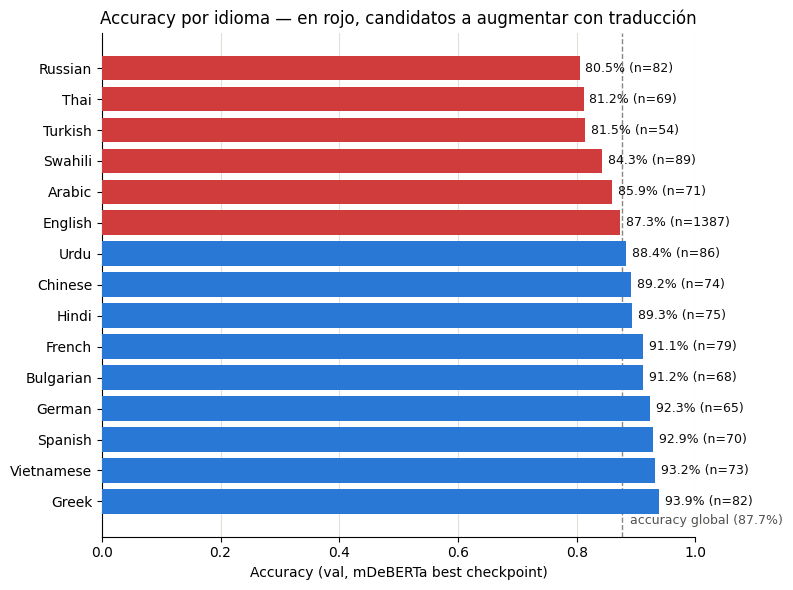

In [33]:
colors = ['#d03b3b' if acc < overall_acc_nli else '#2a78d6' for acc in lang_acc['accuracy']]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(lang_acc.index, lang_acc['accuracy'], color=colors, zorder=3)
ax.axvline(overall_acc_nli, color='#898781', linewidth=1, linestyle='--', zorder=2)
ax.text(overall_acc_nli, len(lang_acc) - 0.4, f'  accuracy global ({overall_acc_nli:.1%})',
        color='#52514e', fontsize=9, va='center')

ax.set_xlim(0, 1)
ax.set_xlabel('Accuracy (val, mDeBERTa best checkpoint)')
ax.set_title('Accuracy por idioma — en rojo, candidatos a augmentar con traducción')
ax.invert_yaxis()  # peor arriba
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

for bar, acc, n in zip(bars, lang_acc['accuracy'], lang_acc['n']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{acc:.1%} (n={n})', va='center', fontsize=9, color='#0b0b0b')

plt.tight_layout()
plt.show()

Comparación final frente al baseline:

In [34]:
comparison = pd.DataFrame([
    {'modelo': 'bert-base-multilingual-cased (baseline, full fine-tune)', 'val_accuracy': baseline_best_val_accuracy},
    {'modelo': 'mDeBERTa-v3-base-mnli-xnli (transfer learning, freezing)', 'val_accuracy': nli_best_val_accuracy},
])
comparison

,modelo,val_accuracy
0,"bert-base-multilingual-cased (baseline, full f...",0.658828
1,"mDeBERTa-v3-base-mnli-xnli (transfer learning,...",0.877063


## Mejora: data augmentation por traducción (ruso, tailandés, turco)

Del análisis de accuracy por idioma de arriba, los tres peores fueron ruso (80.5%), tailandés (81.2%) y turco (81.5%), todos por debajo de la accuracy global (87.7%). Probamos si dar al modelo más ejemplos de entrenamiento en esos idiomas ayuda.

Generamos ~300 ejemplos sintéticos por idioma traduciendo premise/hypothesis desde inglés (el idioma con más datos en el train set y la mejor calidad de traducción automática hacia estos tres) con [`facebook/nllb-200-distilled-600M`](https://huggingface.co/facebook/nllb-200-distilled-600M), un modelo many-to-many que cubre ruso, tailandés y turco directamente desde inglés en un único modelo. La label original se mantiene sin cambios: traducir premise e hypothesis no cambia la relación de entailment/neutral/contradiction entre ellas.

Los ~900 ejemplos aumentados se añaden **solo al split de entrenamiento** (nunca a `val_idx`), para que la comparación de accuracy antes/después siga midiéndose sobre el mismo conjunto de validación que ya usamos.

In [35]:
from transformers import AutoModelForSeq2SeqLM

translator_name = 'facebook/nllb-200-distilled-600M'
translator_tokenizer = AutoTokenizer.from_pretrained(translator_name)

# liberamos temporalmente la VRAM de los modelos ya entrenados: no se vuelven a usar
model.to('cpu')
model_nli.to('cpu')
torch.cuda.empty_cache()

translator_model = AutoModelForSeq2SeqLM.from_pretrained(translator_name, dtype=torch.float16).to(device)
translator_model.eval()

# codigo NLLB de cada idioma objetivo (siempre traduciendo desde eng_Latn)
NLLB_LANG_CODES = {
    'Russian': ('ru', 'rus_Cyrl'),
    'Thai': ('th', 'tha_Thai'),
    'Turkish': ('tr', 'tur_Latn'),
}
N_AUG_PER_LANG = 300
translate_batch_size = 16

def translate_to(texts, tgt_code):
    translator_tokenizer.src_lang = 'eng_Latn'
    translations = []
    for i in range(0, len(texts), translate_batch_size):
        batch = texts[i:i + translate_batch_size]
        inputs = translator_tokenizer(
            batch, return_tensors='pt', padding=True, truncation=True, max_length=128
        ).to(device)
        with torch.no_grad():
            generated = translator_model.generate(
                **inputs,
                forced_bos_token_id=translator_tokenizer.convert_tokens_to_ids(tgt_code),
                max_new_tokens=128,
                num_beams=1)
        translations.extend(translator_tokenizer.batch_decode(generated, skip_special_tokens=True))
    return translations

english_train_pool = train.iloc[train_idx]
english_train_pool = english_train_pool[english_train_pool.language == 'English']

aug_rows = []
for lang_idx, (language, (lang_abv, tgt_code)) in enumerate(NLLB_LANG_CODES.items()):
    sample = english_train_pool.sample(n=N_AUG_PER_LANG, random_state=SEED + lang_idx)
    translated_premises = translate_to(list(sample.premise.values), tgt_code)
    translated_hypotheses = translate_to(list(sample.hypothesis.values), tgt_code)
    for j, (premise, hypothesis, label) in enumerate(zip(translated_premises, translated_hypotheses, sample.label.values)):
        aug_rows.append({
            'id': f'aug_{lang_abv}_{j}', 'premise': premise, 'hypothesis': hypothesis,
            'lang_abv': lang_abv, 'language': language, 'label': label,
        })
    print(f'{language}: {len(sample)} ejemplos traducidos desde ingles')

aug_df = pd.DataFrame(aug_rows)

# ya no necesitamos el traductor: liberamos su VRAM (model/model_nli se quedan en CPU, no hacen falta mas)
del translator_model
torch.cuda.empty_cache()

aug_df.sample(5, random_state=SEED)

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/512 [00:03<26:27,  3.11s/it]

Loading weights:  62%|██████▏   | 317/512 [00:06<00:03, 60.73it/s]

Loading weights: 100%|██████████| 512/512 [00:06<00:00, 107.39it/s]

Loading weights: 100%|██████████| 512/512 [00:06<00:00, 80.25it/s] 

...

[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Turkish: 300 ejemplos traducidos desde ingles


,id,premise,hypothesis,lang_abv,language,label
70,aug_ru_70,"Ах, мадемуазель, нет! - ответил Пуаро откровенно.","Я спросил Пуарота, нравится ли ему кошки, и он...",ru,Russian,1
827,aug_tr_227,Köprü çok kısa süre çalışacaktır ama akım açık...,Köprüyü uzun süre kullanamayacak kadar çok düş...,tr,Turkish,1
231,aug_ru_231,"Впервые я подумал о том, чтобы взять свой тала...","Оказывается, я бы был довольно хорош на этом р...",ru,Russian,1
588,aug_th_288,การ พิมพ์ ไม้ ไม้ ยูคิโออี ที่ สวย สี และ การว...,มีเพียงสถานที่เดียวที่จะซื้อภาพวาดไม้และภาพวาด,th,Thai,2
39,aug_ru_39,"Вместо того, чтобы погружаться в привычную сле...",Уилл такой эксперт в объяснении деталей бейсбола.,ru,Russian,0


Con los ~900 ejemplos aumentados construimos un nuevo set de entrenamiento: el train original (`train_idx`) más `aug_df`. El split de validación (`val_idx` / `val_loader_nli`) no se toca, así medimos el efecto real de la augmentación sobre el mismo conjunto de evaluación usado hasta ahora.

Entrenamos un modelo `model_nli_aug` nuevo desde cero (mismo checkpoint preentrenado `mDeBERTa-v3-base-mnli-xnli`), con la misma configuración que dio el mejor resultado hasta ahora — `K=3` capas superiores entrenables, `dropout=0.4`, mean pooling, `weight_decay=0.1` — para que la única diferencia frente al modelo anterior sea la augmentación de datos, y cualquier cambio en accuracy se le pueda atribuir a eso. Con más datos (~10.600 filas vs ~9.700) le damos algo más de margen de entrenamiento: `epochs=5` con `patience=3`, en vez de los 2 fijos que usamos antes para reproducir la mejor época ya conocida.

In [36]:
train_aug_df = pd.concat([train.iloc[train_idx], aug_df], ignore_index=True)
train_labels_aug = torch.tensor(train_aug_df.label.values, dtype=torch.long)

train_input_nli_aug = bert_encode(train_aug_df.premise.values, train_aug_df.hypothesis.values, tokenizer_nli)
train_dataset_nli_aug = NLIDataset(train_input_nli_aug, train_labels_aug)
train_loader_nli_aug = DataLoader(train_dataset_nli_aug, batch_size=batch_size, shuffle=True)

print(f'Train original: {len(train_idx)} filas -> train aumentado: {len(train_aug_df)} filas (+{len(aug_df)})')

Train original: 9696 filas -> train aumentado: 10596 filas (+900)


In [37]:
model_nli_aug = NLIModel(model_name_nli, dropout=0.4, pooling='mean').float().to(device)

for name, param in model_nli_aug.bert.named_parameters():
    if name.startswith('encoder.layer.'):
        layer_idx = int(name.split('.')[2])
        param.requires_grad = layer_idx >= (model_nli_aug.bert.config.num_hidden_layers - K)
    else:
        param.requires_grad = False

for param in model_nli_aug.classifier.parameters():
    param.requires_grad = True

trainable_params_nli_aug = sum(p.numel() for p in model_nli_aug.parameters() if p.requires_grad)
print(f'Parametros entrenables: {trainable_params_nli_aug:,}')

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 3056.56it/s]


[transformers] DebertaV2Model LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.bias     | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parametros entrenables: 21,265,923


In [38]:
optimizer_nli_aug = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_nli_aug.parameters()), lr=2e-5, weight_decay=0.1)

epochs_nli_aug = 5
patience_nli_aug = 3
total_steps_nli_aug = len(train_loader_nli_aug) * epochs_nli_aug
scheduler_nli_aug = get_linear_schedule_with_warmup(
    optimizer_nli_aug,
    num_warmup_steps=int(0.1 * total_steps_nli_aug),
    num_training_steps=total_steps_nli_aug)

best_val_loss_nli_aug = float('inf')
nli_aug_best_val_accuracy = None
epochs_no_improve_nli_aug = 0

for epoch in range(epochs_nli_aug):
    model_nli_aug.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for batch in train_loader_nli_aug:
        optimizer_nli_aug.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        logits = model_nli_aug(input_ids, attention_mask, token_type_ids)
        loss = criterion(logits, batch_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_nli_aug.parameters(), max_norm=1.0)
        optimizer_nli_aug.step()
        scheduler_nli_aug.step()

        train_loss += loss.item() * batch_labels.size(0)
        train_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    model_nli_aug.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader_nli:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            batch_labels = batch['label'].to(device)

            logits = model_nli_aug(input_ids, attention_mask, token_type_ids)
            loss = criterion(logits, batch_labels)

            val_loss += loss.item() * batch_labels.size(0)
            val_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
            val_total += batch_labels.size(0)

    nli_aug_val_accuracy = val_correct / val_total
    avg_val_loss_nli_aug = val_loss / val_total
    print(f'Epoch {epoch+1}/{epochs_nli_aug} - '
          f'loss: {train_loss/train_total:.4f} - accuracy: {train_correct/train_total:.4f} - '
          f'val_loss: {avg_val_loss_nli_aug:.4f} - val_accuracy: {nli_aug_val_accuracy:.4f}')

    # Checkpointing: "last" se sobrescribe cada epoch, "best" solo cuando mejora la val_loss
    torch.save(model_nli_aug.state_dict(), os.path.join(checkpoint_dir, 'nli_aug_last.pt'))

    if avg_val_loss_nli_aug < best_val_loss_nli_aug:
        best_val_loss_nli_aug = avg_val_loss_nli_aug
        nli_aug_best_val_accuracy = nli_aug_val_accuracy
        epochs_no_improve_nli_aug = 0
        torch.save(model_nli_aug.state_dict(), os.path.join(checkpoint_dir, 'nli_aug_best.pt'))
        print(f'  -> nuevo mejor val_loss ({best_val_loss_nli_aug:.4f}), guardado en nli_aug_best.pt')
    else:
        epochs_no_improve_nli_aug += 1
        print(f'  -> val_loss sin mejora desde hace {epochs_no_improve_nli_aug} epoch(s) (mejor: {best_val_loss_nli_aug:.4f})')
        if epochs_no_improve_nli_aug >= patience_nli_aug:
            print(f'Early stopping: sin mejora en val_loss durante {patience_nli_aug} epochs consecutivos.')
            break

Epoch 1/5 - loss: 0.5833 - accuracy: 0.7552 - val_loss: 0.3424 - val_accuracy: 0.8775


  -> nuevo mejor val_loss (0.3424), guardado en nli_aug_best.pt


Epoch 2/5 - loss: 0.3736 - accuracy: 0.8635 - val_loss: 0.3497 - val_accuracy: 0.8762


  -> val_loss sin mejora desde hace 1 epoch(s) (mejor: 0.3424)


Epoch 3/5 - loss: 0.3316 - accuracy: 0.8824 - val_loss: 0.3394 - val_accuracy: 0.8841


  -> nuevo mejor val_loss (0.3394), guardado en nli_aug_best.pt


Epoch 4/5 - loss: 0.3027 - accuracy: 0.8898 - val_loss: 0.3497 - val_accuracy: 0.8853


  -> val_loss sin mejora desde hace 1 epoch(s) (mejor: 0.3394)


Epoch 5/5 - loss: 0.2876 - accuracy: 0.8985 - val_loss: 0.3554 - val_accuracy: 0.8841


  -> val_loss sin mejora desde hace 2 epoch(s) (mejor: 0.3394)


Recargamos el mejor checkpoint (`nli_aug_best.pt`) y evaluamos sobre el mismo `val_loader_nli` de siempre, para comparar accuracy por idioma antes/después de la augmentación — sobre todo en ruso, tailandés y turco, que es lo que queríamos mejorar.

In [39]:
model_nli_aug.load_state_dict(torch.load(os.path.join(checkpoint_dir, 'nli_aug_best.pt')))
model_nli_aug.eval()

val_preds_nli_aug, val_true_nli_aug = [], []
with torch.no_grad():
    for batch in val_loader_nli:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        logits = model_nli_aug(input_ids, attention_mask, token_type_ids)
        val_preds_nli_aug.extend(logits.argmax(dim=-1).cpu().tolist())
        val_true_nli_aug.extend(batch_labels.cpu().tolist())

lang_df_aug = pd.DataFrame({'language': val_lang_nli, 'true': val_true_nli_aug, 'pred': val_preds_nli_aug})
lang_df_aug['correct'] = lang_df_aug['true'] == lang_df_aug['pred']
lang_acc_aug = lang_df_aug.groupby('language')['correct'].agg(accuracy='mean', n='size')

before_after = lang_acc[['accuracy']].rename(columns={'accuracy': 'antes'}).join(
    lang_acc_aug[['accuracy']].rename(columns={'accuracy': 'despues'}))
before_after['delta'] = before_after['despues'] - before_after['antes']
before_after.loc['GLOBAL'] = [overall_acc_nli, lang_df_aug['correct'].mean(),
                               lang_df_aug['correct'].mean() - overall_acc_nli]
before_after.sort_values('delta', ascending=False)

,antes,despues,delta
language,,,
Russian,0.804878,0.853659,0.048780
Arabic,0.859155,0.887324,0.028169
Turkish,0.814815,0.833333,0.018519
Greek,0.939024,0.951220,0.012195
Swahili,0.842697,0.853933,0.011236
English,0.873107,0.883922,0.010815
GLOBAL,0.877063,0.884076,0.007013
Thai,0.811594,0.811594,0.000000
German,0.923077,0.923077,0.000000


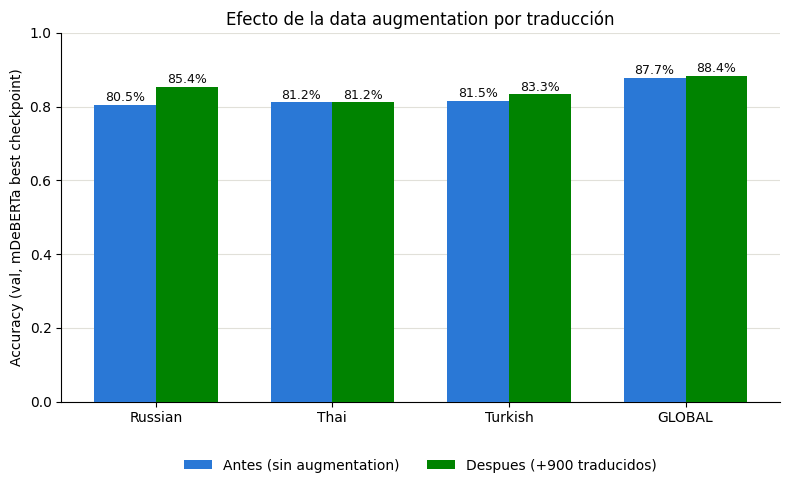

In [40]:
plot_langs = ['Russian', 'Thai', 'Turkish', 'GLOBAL']
plot_df = before_after.loc[plot_langs]

x = np.arange(len(plot_langs))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_before = ax.bar(x - width / 2, plot_df['antes'], width, label='Antes (sin augmentation)',
                      color='#2a78d6', zorder=3)
bars_after = ax.bar(x + width / 2, plot_df['despues'], width, label='Despues (+900 traducidos)',
                     color='#008300', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(plot_langs)
ax.set_ylabel('Accuracy (val, mDeBERTa best checkpoint)')
ax.set_title('Efecto de la data augmentation por traducción')
ax.set_ylim(0, 1)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)

for bars in (bars_before, bars_after):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{bar.get_height():.1%}',
                ha='center', fontsize=9, color='#0b0b0b')

plt.tight_layout()
plt.show()

**Resultado:** la augmentación ayudó, pero de forma desigual entre los tres idiomas objetivo — **ruso 80.5% → 85.4%** (+4.9 puntos, el idioma que más se benefició), **turco 81.5% → 83.3%** (+1.9 puntos), pero **tailandés se quedó plano en 81.2%** (sin cambio). La accuracy global subió ligeramente (87.7% → 88.4%, +0.7 puntos), con algún efecto colateral: chino bajó 4.1 puntos y unos pocos idiomas más (búlgaro, hindi, francés, urdu) perdieron 1-1.5 puntos — con n≈65-90 por idioma esto es del orden del ruido de muestreo que ya habíamos señalado, no necesariamente una regresión real.

Que tailandés no mejorara nada es la señal más interesante: puede ser que la traducción automática inglés→tailandés de NLLB sea de peor calidad que hacia ruso/turco (idiomas tipológicamente más cercanos al inglés), introduciendo ruido en vez de señal útil, o que 300 ejemplos no sean suficientes para ese idioma en concreto. Antes de aumentar el volumen de augmentación para tailandés, valdría la pena inspeccionar a mano una muestra de las traducciones generadas para descartar que sean de mala calidad.

## Ensemble: promediar `nli_best.pt` (sin augmentation) y `nli_aug_best.pt` (con augmentation)

Ya tenemos dos checkpoints entrenados sobre el mismo split de validación: el modelo original y el entrenado con los ~900 ejemplos traducidos. Antes de plantear cualquier reentrenamiento nuevo, probamos el ensemble más simple y barato posible — no hace falta entrenar nada más, solo recargar ambos checkpoints y promediar sus probabilidades softmax en cada ejemplo de `val_loader_nli` (`(softmax_a + softmax_b) / 2`, luego argmax).

La lógica: son dos modelos con la misma arquitectura pero pesos distintos (uno vio más ejemplos de ruso/tailandés/turco que el otro), así que sus errores no tienen por qué coincidir — si aciertan en ejemplos distintos, promediarlos puede superar a cualquiera de los dos por separado.

In [41]:
model_nli.to(device)
model_nli.eval()
model_nli_aug.eval()

val_true_ens, val_preds_ens = [], []
with torch.no_grad():
    for batch in val_loader_nli:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        probs_a = torch.softmax(model_nli(input_ids, attention_mask, token_type_ids), dim=-1)
        probs_b = torch.softmax(model_nli_aug(input_ids, attention_mask, token_type_ids), dim=-1)
        ensemble_probs = (probs_a + probs_b) / 2

        val_preds_ens.extend(ensemble_probs.argmax(dim=-1).cpu().tolist())
        val_true_ens.extend(batch_labels.cpu().tolist())

lang_df_ens = pd.DataFrame({'language': val_lang_nli, 'true': val_true_ens, 'pred': val_preds_ens})
lang_df_ens['correct'] = lang_df_ens['true'] == lang_df_ens['pred']
lang_acc_ens = lang_df_ens.groupby('language')['correct'].agg(accuracy='mean', n='size')
overall_acc_ens = lang_df_ens['correct'].mean()

comparison_3way = pd.DataFrame({
    'sin_augmentation': lang_acc['accuracy'],
    'con_augmentation': lang_acc_aug['accuracy'],
    'ensemble': lang_acc_ens['accuracy'],
})
comparison_3way.loc['GLOBAL'] = [overall_acc_nli, lang_df_aug['correct'].mean(), overall_acc_ens]
comparison_3way['mejor'] = comparison_3way[['sin_augmentation', 'con_augmentation', 'ensemble']].idxmax(axis=1)
comparison_3way.sort_values('ensemble', ascending=False)

,sin_augmentation,con_augmentation,ensemble,mejor
language,,,,
Greek,0.939024,0.951220,0.939024,con_augmentation
Vietnamese,0.931507,0.931507,0.931507,sin_augmentation
Spanish,0.928571,0.928571,0.928571,sin_augmentation
German,0.923077,0.923077,0.923077,sin_augmentation
French,0.911392,0.898734,0.911392,sin_augmentation
Bulgarian,0.911765,0.897059,0.897059,sin_augmentation
Arabic,0.859155,0.887324,0.887324,con_augmentation
GLOBAL,0.877063,0.884076,0.881188,con_augmentation
Hindi,0.893333,0.880000,0.880000,sin_augmentation


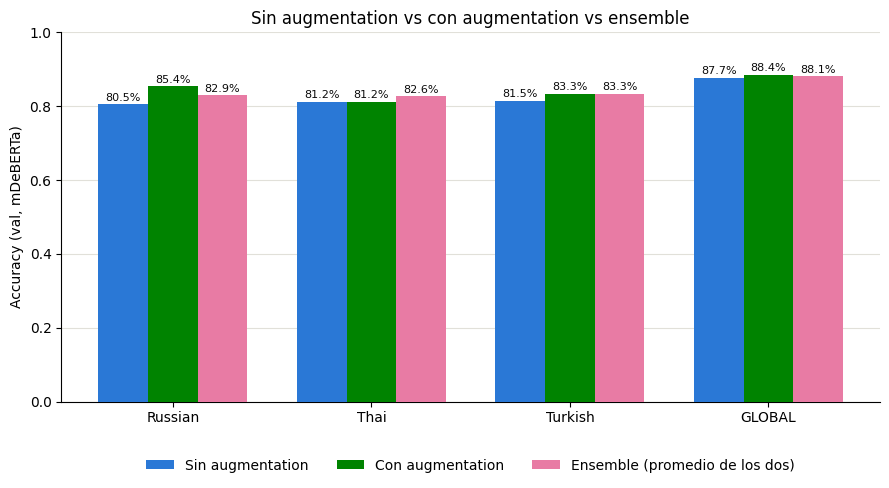

In [42]:
plot_langs = ['Russian', 'Thai', 'Turkish', 'GLOBAL']
plot_df = comparison_3way.loc[plot_langs]

x = np.arange(len(plot_langs))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
bars_1 = ax.bar(x - width, plot_df['sin_augmentation'], width, label='Sin augmentation',
                 color='#2a78d6', zorder=3)
bars_2 = ax.bar(x, plot_df['con_augmentation'], width, label='Con augmentation',
                 color='#008300', zorder=3)
bars_3 = ax.bar(x + width, plot_df['ensemble'], width, label='Ensemble (promedio de los dos)',
                 color='#e87ba4', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(plot_langs)
ax.set_ylabel('Accuracy (val, mDeBERTa)')
ax.set_title('Sin augmentation vs con augmentation vs ensemble')
ax.set_ylim(0, 1)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

for bars in (bars_1, bars_2, bars_3):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{bar.get_height():.1%}',
                ha='center', fontsize=8, color='#0b0b0b')

plt.tight_layout()
plt.show()

**Resultado: el ensemble no gana.** Global, `con_augmentation` sola (88.4%) sigue siendo mejor que el ensemble (88.1%), que a su vez supera a `sin_augmentation` sola (87.7%). Para ruso y turco el ensemble queda *entre* los dos modelos individuales, nunca por encima del mejor de los dos — al promediar, `model_nli` (que seguía siendo bastante peor en ruso, 80.5%) arrastra hacia abajo el 85.4% que había conseguido `model_nli_aug` en solitario (ruso: ensemble 82.9%, un punto y medio por debajo de usar solo el modelo con augmentation).

La única excepción es tailandés: ahí `sin_augmentation` y `con_augmentation` empataban exactos en 81.2% (la augmentación no había movido ni un ejemplo), pero el ensemble sube a 82.6% — señal de que en ese idioma concreto los dos modelos sí aciertan en ejemplos distintos y se complementan un poco, aunque no compensa la pérdida en el resto de idiomas.

**Conclusión práctica:** para este par de checkpoints concretos, quedarse con `nli_aug_best.pt` (con augmentation) a secas es mejor que promediarlo con el modelo sin augmentation — tiene sentido, porque los dos modelos comparten casi todo el training set (solo difieren en ~900 de ~10.600 filas) y por tanto sus errores están muy correlacionados, justo lo contrario de lo que necesita un ensemble para sumar. Si se quiere seguir explorando ensembling, probablemente haga falta diversidad real entre los modelos (distintas seeds, distinto `K`, distinto pooling, o incluso arquitecturas distintas) en vez de dos variantes casi idénticas del mismo modelo.